In [1]:
import importlib
from RSA_nD_tuner import *
import RSA_nD_tuner
importlib.reload(RSA_nD_tuner)
from RSA_nD_tuner import *

ModuleNotFoundError: No module named 'RSA_nD_tuner'

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

### Flow map
Now that we have a grid over the $(a,b)$-plane we can visualize the loss landscape. Below the red dot represents the base parameterization from which all other points are reweighed from. The green start is the target parameterization where the loss function (in this case the psuedo-$\chi^2$) should be at a minimum. The arrow represent the gradients of $a$ and $b$ at each grid point.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# -- Load data for the chosen plot --
plot_nm = '72'
gradients     = np.load(f'temp_results/Flow_map/4D/gradients_{plot_nm}.npy')
magnitudes    = np.load(f'temp_results/Flow_map/4D/magnitudes_{plot_nm}.npy')
loss_grid     = np.load(f'temp_results/Flow_map/4D/loss_grid_{plot_nm}.npy')
mu_sigmamu    = np.load(f'temp_results/Flow_map/4D/mu_{plot_nm}.npy')
Neff          = np.load(f'temp_results/Flow_map/4D/Neff_{plot_nm}.npy')
mu, sigmamu   = mu_sigmamu[:, 0], mu_sigmamu[:, 1]
params_grid   = np.load(f'temp_results/Flow_map/4D/params_grid_{plot_nm}.npy')
ordered_params = np.load(f'temp_results/Flow_map/4D/ordered_params_{plot_nm}.npy')


# Configuration per plot_nm: scale and base/target points
plot3d_configs = {
    '1': {'scale': 1e3, 'base': (0.68, 0.98, 0.68, 0.335), 'target': (0.68, 0.98, 0.68, 0.335)},
}
config = plot3d_configs.get(plot_nm)
if config is None:
    raise ValueError(f"Unsupported plot_nm: {plot_nm}")

# Unpack coordinates and gradients
ad, bd, sig = a_b_c[:, 0], a_b_c[:, 1], a_b_c[:, 2]
g1, g2, g3  = -a_b_gradients[:, 0], -a_b_gradients[:, 1], -a_b_gradients[:, 2]

# Create 3D figure
fig = plt.figure(figsize=(10, 8))
ax  = fig.add_subplot(111, projection='3d')

# Plot base and target
ax.scatter(*config['base'],  marker='o', color='black', s=50, label='base')
ax.scatter(*config['target'], marker='o', color='red',   s=50, label='target')

# Quiver for gradient field
ax.quiver(ad, bd, sig,
          g1 / config['scale'],
          g2 / config['scale'],
          g3 / config['scale'],
          length=1.0, normalize=False)

# Scatter colored by loss value
sc = ax.scatter(ad, bd, sig,
                # c=np.log10(loss_grid), cmap='plasma',
                c=Neff, cmap='plasma',
                s=20, alpha=0.8)
cbar = fig.colorbar(sc, pad=0.1)
cbar.set_label('log10(loss)')

# Labels and legend
ax.set_xlabel('a_d')
ax.set_ylabel('b_d')
ax.set_zlabel('sigma')
ax.set_title(f'3D Loss Landscape and Gradients (plot {plot_nm})')
ax.legend()
plt.tight_layout()
plt.show()


/tmp/ipykernel_1628186/2280414358.py:54: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


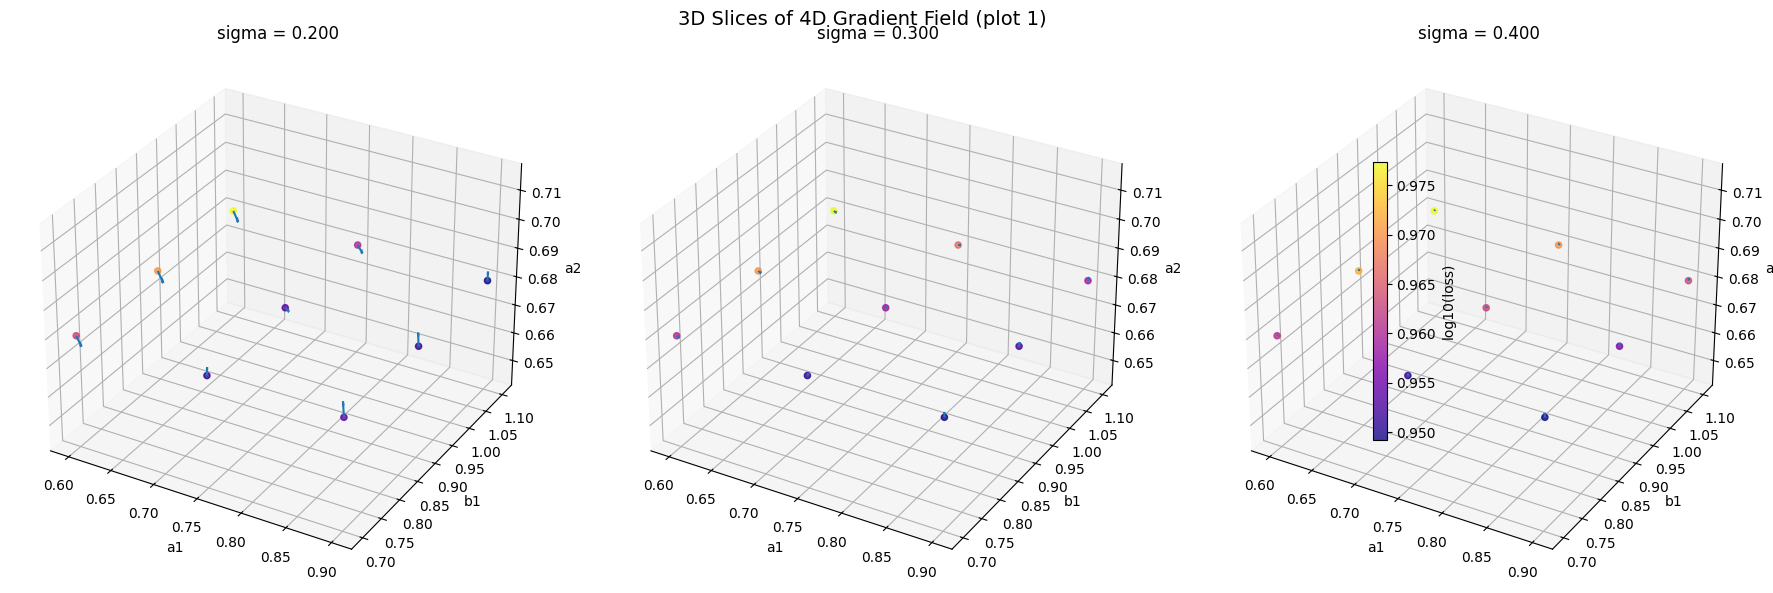

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# -- Load data --
plot_nm = '1'
gradients     = np.load(f'temp_results/Flow_map/4D/gradients_{plot_nm}.npy')
loss_grid     = np.load(f'temp_results/Flow_map/4D/loss_grid_{plot_nm}.npy')
mu_sigmamu    = np.load(f'temp_results/Flow_map/4D/mu_{plot_nm}.npy')
Neff          = np.load(f'temp_results/Flow_map/4D/Neff_{plot_nm}.npy')
params_grid   = np.load(f'temp_results/Flow_map/4D/params_grid_{plot_nm}.npy')  # shape: (N, 4)
ordered_params = np.load(f'temp_results/Flow_map/4D/ordered_params_{plot_nm}.npy')

# -- Plot config --
fixed_param_index = 3  # fix the 4th param (index in ordered_params)
fixed_param_name  = ordered_params[fixed_param_index]
unique_fixed_vals = np.unique(params_grid[:, fixed_param_index])

# -- Plot settings --
scale = 1e3
scatter_metric = np.log10(loss_grid)  # or Neff
num_slices = min(len(unique_fixed_vals), 4)

# Loop over a few slices
fig = plt.figure(figsize=(6 * num_slices, 6))
for i, val in enumerate(unique_fixed_vals[:num_slices]):
    ax = fig.add_subplot(1, num_slices, i + 1, projection='3d')

    # Get 3D slice where the fixed param = val
    mask = params_grid[:, fixed_param_index] == val
    sliced_params = params_grid[mask]
    sliced_grads = -gradients[mask]  # minus gradient = descent direction
    sliced_loss = scatter_metric[mask]

    # Determine indices for the 3 varying params
    varying_indices = [j for j in range(4) if j != fixed_param_index]
    X, Y, Z = sliced_params[:, varying_indices[0]], sliced_params[:, varying_indices[1]], sliced_params[:, varying_indices[2]]
    U, V, W = sliced_grads[:, varying_indices[0]] / scale, sliced_grads[:, varying_indices[1]] / scale, sliced_grads[:, varying_indices[2]] / scale

    # Plot quiver
    ax.quiver(X, Y, Z, U, V, W, length=1.0, normalize=False)

    # Scatter colored by loss or Neff
    sc = ax.scatter(X, Y, Z, c=sliced_loss, cmap='plasma', s=20, alpha=0.8)
    
    ax.set_xlabel(ordered_params[varying_indices[0]])
    ax.set_ylabel(ordered_params[varying_indices[1]])
    ax.set_zlabel(ordered_params[varying_indices[2]])
    ax.set_title(f'{fixed_param_name} = {val:.3f}')

cbar = fig.colorbar(sc, ax=fig.get_axes(), shrink=0.6, location='right')
cbar.set_label('log10(loss)')
fig.suptitle(f'3D Slices of 4D Gradient Field (plot {plot_nm})', fontsize=14)
plt.tight_layout()
plt.savefig(f'/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/Flow_map/4D/images/1_{plot_nm}.png')
plt.show()